In [1]:
# https://raw.githubusercontent.com/nkmwicz/worldcup2018data/
# refs/heads/main/cleaned_events_world_cup2018.csv

import pandas as pd, scipy.stats as stats
import matplotlib.pyplot as plt, seaborn as sns

url = "https://raw.githubusercontent.com/nkmwicz/worldcup2018data/refs/heads/main/cleaned_events_world_cup2018.csv"
df = pd.read_csv(url)
for col in df.columns:
    print(col)
df.head(1)

eventId
subEventName
tags
playerId
matchId
eventName
teamId
matchPeriod
eventSec
subEventId
id
x1
y1
x2
y2


,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2
0,8,Simple pass,['Accurate'],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0


In [2]:
df["eventName"].unique()

<StringArray>
[                   'Pass',                    'Duel',
               'Free Kick',                    'Foul',
      'Others on the ball',                    'Shot',
            'Save attempt',                 'Offside',
 'Goalkeeper leaving line']
Length: 9, dtype: str

In [3]:
df["pass"] = (df["eventName"] == "Pass").astype(int)
df["shot"] = (df["eventName"] == "Shot").astype(int)
df.head()

,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2,pass,shot
0,8,Simple pass,['Accurate'],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0,1,0
1,8,High pass,['Accurate'],Abdullah Ibrahim Otayf,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,4.487814,High pass,258612106,35,53,75.0,19.0,1,0
2,1,Air duel,"['Won', 'Accurate']",Ilya Kutepov,"Russia - Saudi Arabia, 5 - 0",Duel,Russia,1H,5.937411,Air duel,258612077,25,81,37.0,83.0,0,0
3,1,Air duel,"['Lost', 'Not accurate']",Yasir Gharsan Al Shahrani,"Russia - Saudi Arabia, 5 - 0",Duel,Saudi Arabia,1H,6.406961,Air duel,258612112,75,19,63.0,17.0,0,0
4,8,Simple pass,['Accurate'],Salman Mohammed Al Faraj,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,8.562167,Simple pass,258612110,63,17,71.0,15.0,1,0


In [4]:
for i in df["matchId"].unique():
    print(i)

Russia - Saudi Arabia, 5 - 0
Egypt - Uruguay, 0 - 1
Russia - Egypt, 3 - 1
Uruguay - Saudi Arabia, 1 - 0
Uruguay - Russia, 3 - 0
Saudi Arabia - Egypt, 2 - 1
Portugal - Spain, 3 - 3
Morocco - Iran, 0 - 1
Portugal - Morocco, 1 - 0
Iran - Spain, 0 - 1
Iran - Portugal, 1 - 1
Spain - Morocco, 2 - 2
France - Australia, 2 - 1
Peru - Denmark, 0 - 1
France - Peru, 1 - 0
Denmark - Australia, 1 - 1
Denmark - France, 0 - 0
Australia - Peru, 0 - 2
Argentina - Iceland, 1 - 1
Croatia - Nigeria, 2 - 0
Argentina - Croatia, 0 - 3
Nigeria - Iceland, 2 - 0
Nigeria - Argentina, 1 - 2
Iceland - Croatia, 1 - 2
Brazil - Switzerland, 1 - 1
Costa Rica - Serbia, 0 - 1
Brazil - Costa Rica, 2 - 0
Serbia - Switzerland, 1 - 2
Serbia - Brazil, 0 - 2
Switzerland - Costa Rica, 2 - 2
Germany - Mexico, 0 - 1
Sweden - Korea Republic, 1 - 0
Germany - Sweden, 2 - 1
Korea Republic - Mexico, 1 - 2
Korea Republic - Germany, 2 - 0
Mexico - Sweden, 0 - 3
Belgium - Panama, 3 - 0
Tunisia - England, 1 - 2
Belgium - Tunisia, 5 - 2
En

In [7]:
def get_outcome(row):
    teamId = row["teamId"]
    match:str = row["matchId"]
    match = match.split(" (")[0]
    teams, scores = match.split(",")
    t1, t2 = teams.split(" - ")
    s1, s2 = scores.split(" - ")
    s1 = int(s1)
    s2 = int(s2)
    if teamId == t1:
        if s1 > s2:
            return "win"
        elif s2 > s1:
            return "loss"
        else:
            return "draw"
    if teamId == t2:
        if s2 > s1:
            return "win"
        elif s1 > s2:
            return "loss"
        else:
            return "draw"
    
df["outcome"] = df.apply(get_outcome, axis=1)

In [8]:
df.groupby(["matchId", "teamId"]).agg({"outcome": "first"}).value_counts()

outcome
loss       51
win        51
draw       26
Name: count, dtype: int64

In [9]:
grp_df = df.groupby(["matchId", "teamId"]).agg(
    passes=("pass", "sum"),
    shots=("shot", "sum"), 
    outcome=("outcome", "first"),
).reset_index()
grp_df

,matchId,teamId,passes,shots,outcome
0,"Argentina - Croatia, 0 - 3",Argentina,476,10,loss
1,"Argentina - Croatia, 0 - 3",Croatia,334,13,win
2,"Argentina - Iceland, 1 - 1",Argentina,744,22,draw
3,"Argentina - Iceland, 1 - 1",Iceland,183,8,draw
4,"Australia - Peru, 0 - 2",Australia,512,11,loss
...,...,...,...,...,...
123,"Uruguay - Portugal, 2 - 1",Uruguay,238,6,win
124,"Uruguay - Russia, 3 - 0",Russia,327,3,loss
125,"Uruguay - Russia, 3 - 0",Uruguay,466,12,win
126,"Uruguay - Saudi Arabia, 1 - 0",Saudi Arabia,553,7,loss


In [11]:
cats = grp_df["outcome"].unique()
p_samples = [grp_df.loc[grp_df["outcome"] == c, "passes"] for c in cats]

f,p = stats.f_oneway(*p_samples)
dfw = sum([len(s) for s in p_samples]) - len(p_samples) # p_samples = [[], [], []]
dfb = len(p_samples) - 1
alpha = 0.05
cf = stats.f.ppf(1-alpha, dfb, dfw)
print(f"f={f:.4f}, critical={cf:.4f}, p={p:.4f}")

f=2.2838, critical=3.0687, p=0.1061


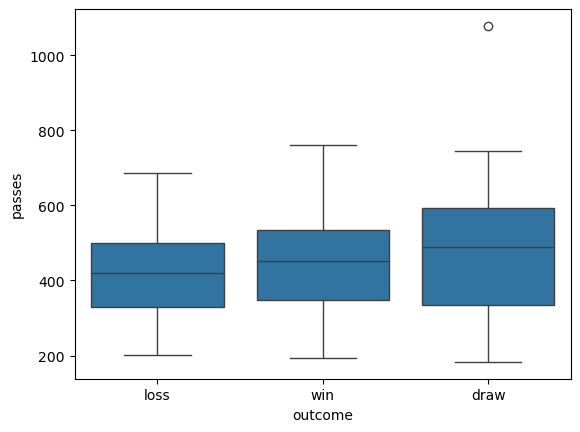

In [12]:
box = sns.boxplot(data=grp_df, x="outcome", y="passes")

In [13]:
loss = grp_df.loc[grp_df["outcome"] == "loss", "passes"]
n_loss = grp_df.loc[grp_df["outcome"] != "loss", "passes"]

t, p = stats.ttest_ind(loss, n_loss)

deg_f = len(loss) + len(n_loss) - 2
ct = stats.t.ppf(1-alpha/2, deg_f)

print(f"t={t:.4f}, critical={ct:.4f}, p={p:.4f}")


t=-1.6951, critical=1.9790, p=0.0925
